In [35]:
import pandas as pd
data= pd.read_csv("./results.csv",sep=",")
data["cost"] = data["processors"]*data["time"]

In [36]:
shared_memory_data = data[data['testtype'] == 'shared memory']
distributed_memory_data = data[data['testtype'] == 'distributed memory']
shared_memory_data

,hostname,testname,testtype,time,processors,solution_weight,solution_profit,capacity,num_items,cost
0,broadwell-045,knapsackdp,shared memory,0.0007,1,983,185,1000,50,0.0007
1,broadwell-045,knapsackcopa,shared memory,1.6145,1,983,185,1000,50,1.6145
2,broadwell-045,knapsackdp,shared memory,0.0020,1,9965,540,10000,50,0.0020
3,broadwell-045,knapsackcopa,shared memory,1.6140,1,9965,540,10000,50,1.6140
4,broadwell-045,knapsackdp,shared memory,0.0177,1,99276,1344,100000,50,0.0177
...,...,...,...,...,...,...,...,...,...,...
67,broadwell-045,knapsackcopa,shared memory,4.8315,32,115520,1369,1000000,50,154.6080
68,broadwell-045,knapsackdp,shared memory,1.0103,32,115520,1369,10000000,50,32.3296
69,broadwell-045,knapsackcopa,shared memory,5.9790,32,115520,1369,10000000,50,191.3280
70,broadwell-045,knapsackdp,shared memory,10.3349,32,115520,1369,100000000,50,330.7168


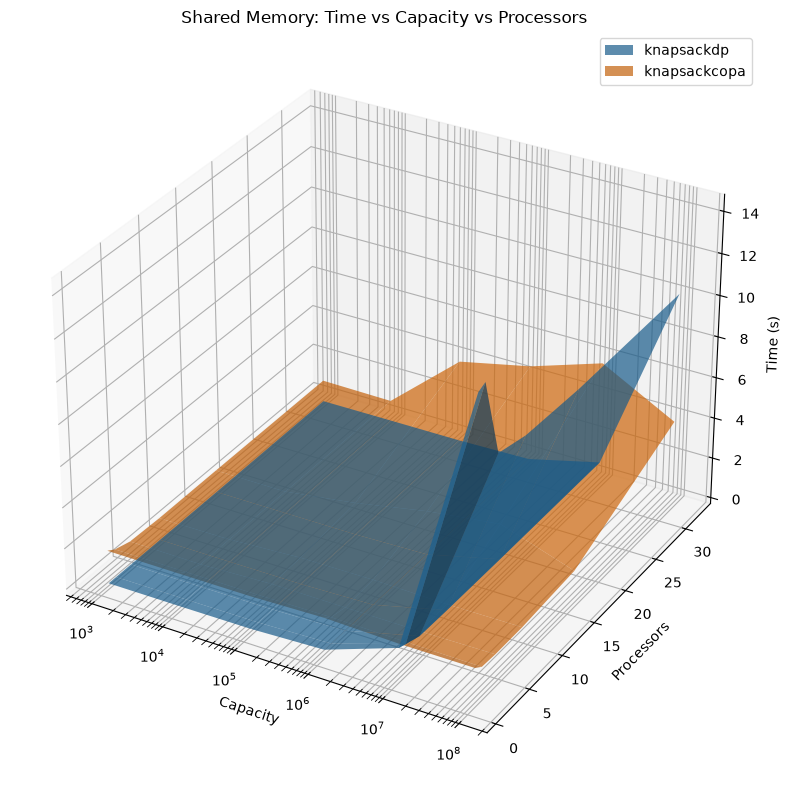

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sm = shared_memory_data

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

capacities = sorted(sm['capacity'].unique())
processors = sorted(sm['processors'].unique())
C, P = np.meshgrid(capacities, processors)

for testname in sm['testname'].unique():
    subset = sm[sm['testname'] == testname]
    Z = subset.pivot_table(index='processors', columns='capacity',
                           values='time').values
    ax.plot_surface(C, P, Z, label=testname, alpha=0.7)

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Time (s)')
ax.set_title('Shared Memory: Time vs Capacity vs Processors')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig("images/t_c_p_shared.png")
plt.show()

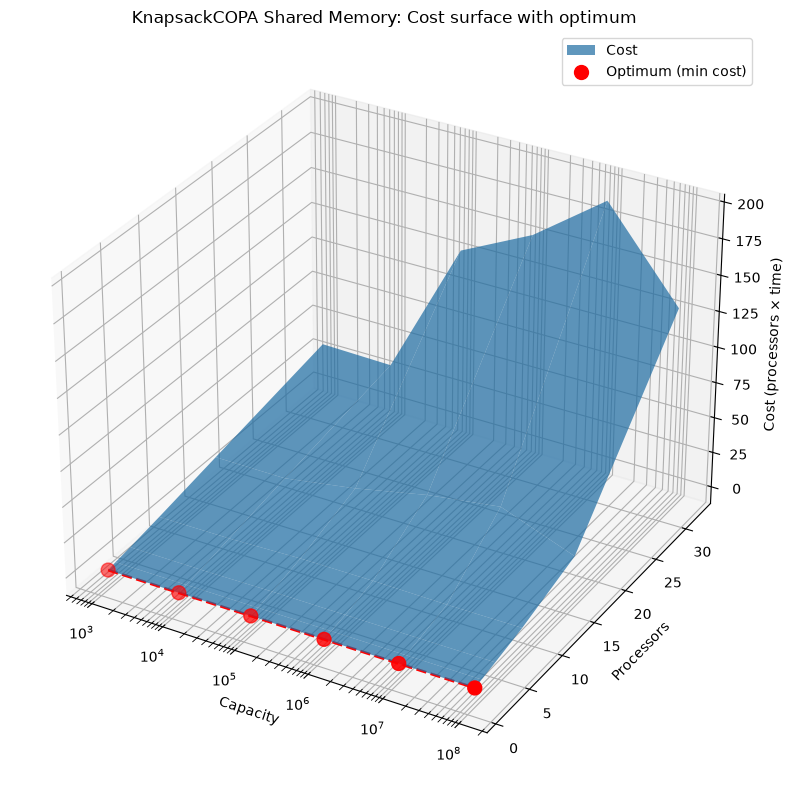

In [38]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

copa = shared_memory_data[shared_memory_data['testname'] == 'knapsackcopa'].copy()
copa['cost'] = copa['processors'] * copa['time']

capacities = sorted(copa['capacity'].unique())
processors = sorted(copa['processors'].unique())
C, P = np.meshgrid(capacities, processors)
Z = copa.pivot_table(index='processors', columns='capacity',
                     values='cost').values

opt_idx = Z.argmin(axis=0)
opt_cost = Z.min(axis=0)
opt_proc = [processors[i] for i in opt_idx]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(C, P, Z, alpha=0.7, label='Cost')
ax.scatter(capacities, opt_proc, opt_cost,
           color='red', s=100, label='Optimum (min cost)')
ax.plot(capacities, opt_proc, opt_cost,
        color='red', linewidth=2, linestyle='--')

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Cost (processors \u00d7 time)')
ax.set_title('KnapsackCOPA Shared Memory: Cost surface with optimum')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

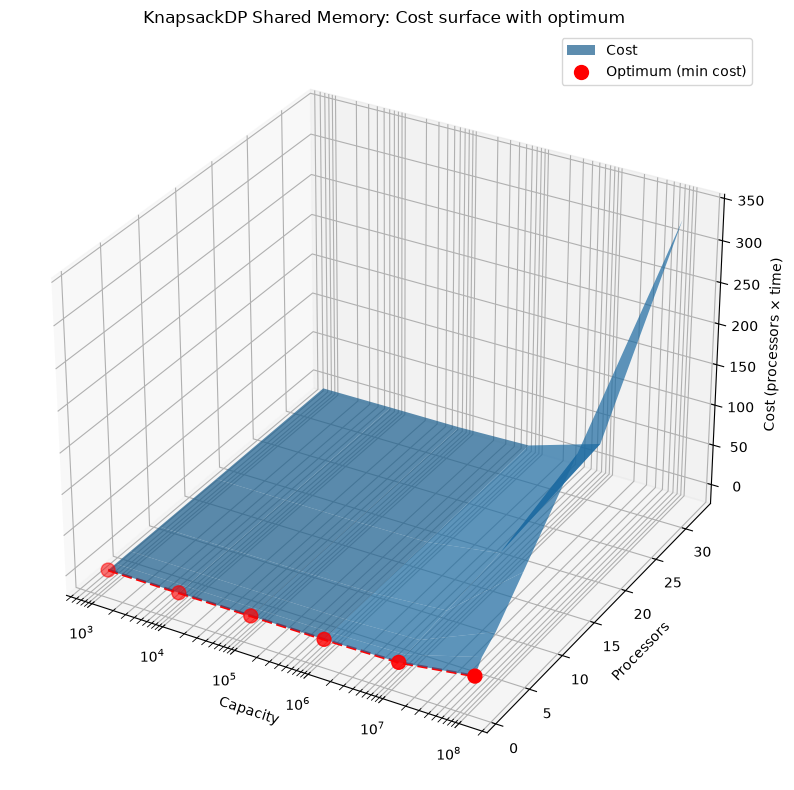

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

dp = shared_memory_data[shared_memory_data['testname'] == 'knapsackdp'].copy()
dp['cost'] = dp['processors'] * dp['time']

capacities = sorted(dp['capacity'].unique())
processors = sorted(dp['processors'].unique())
C, P = np.meshgrid(capacities, processors)
Z = dp.pivot_table(index='processors', columns='capacity',
                   values='cost').values

opt_idx = Z.argmin(axis=0)
opt_cost = Z.min(axis=0)
opt_proc = [processors[i] for i in opt_idx]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(C, P, Z, alpha=0.7, label='Cost')
ax.scatter(capacities, opt_proc, opt_cost,
           color='red', s=100, label='Optimum (min cost)')
ax.plot(capacities, opt_proc, opt_cost,
        color='red', linewidth=2, linestyle='--')

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Cost (processors \u00d7 time)')
ax.set_title('KnapsackDP Shared Memory: Cost surface with optimum')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

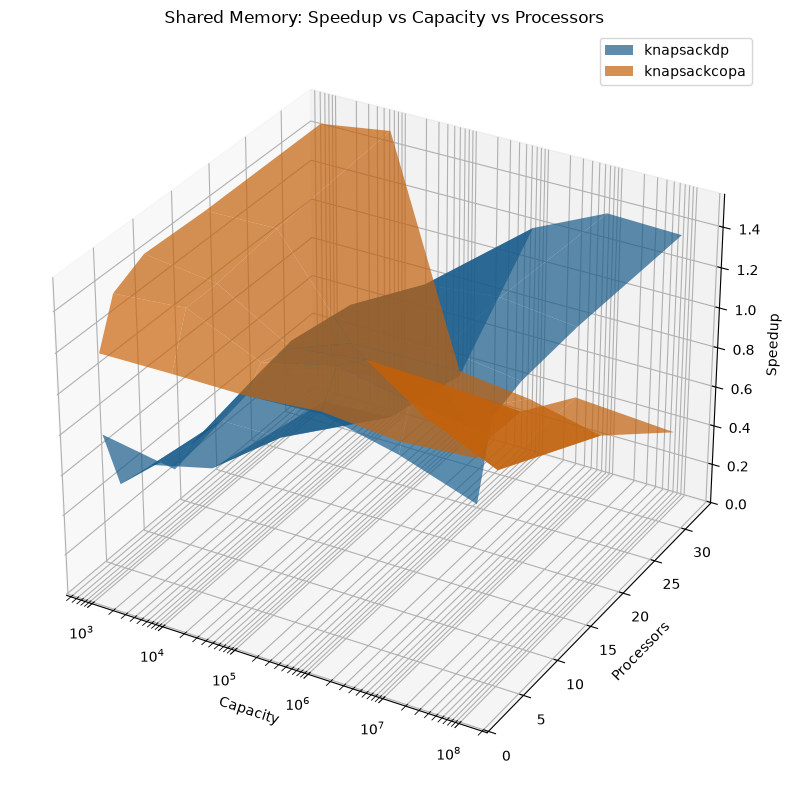

In [40]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sm = data[data['testtype'] == 'shared memory']

baseline = sm[sm['processors'] == 1][['testname', 'capacity', 'time']]
multi = sm[sm['processors'] > 1]

speedup_data = multi.merge(
    baseline, on=['testname', 'capacity'], suffixes=('', '_base')
)
speedup_data['speedup'] = speedup_data['time_base'] / speedup_data['time']

capacities = sorted(speedup_data['capacity'].unique())
processors = sorted(speedup_data['processors'].unique())
C, P = np.meshgrid(capacities, processors)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for testname in speedup_data['testname'].unique():
    subset = speedup_data[speedup_data['testname'] == testname]
    Z = subset.pivot_table(index='processors', columns='capacity',
                           values='speedup').values
    ax.plot_surface(C, P, Z, label=testname, alpha=0.7)

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Speedup')
ax.set_title('Shared Memory: Speedup vs Capacity vs Processors')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

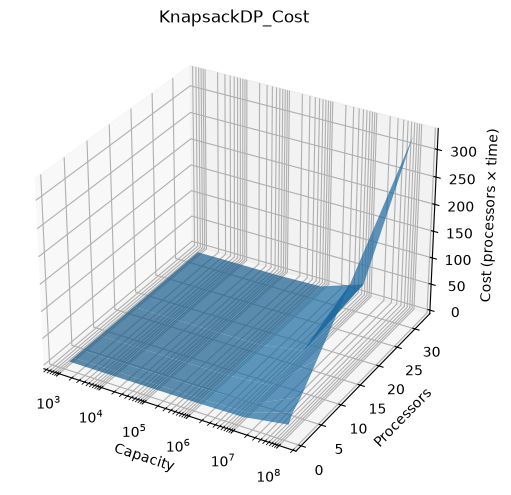

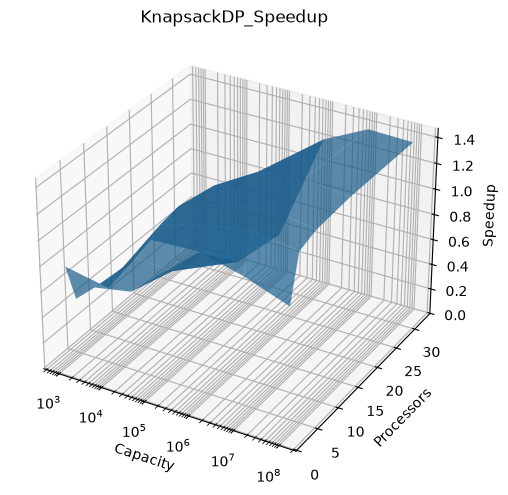

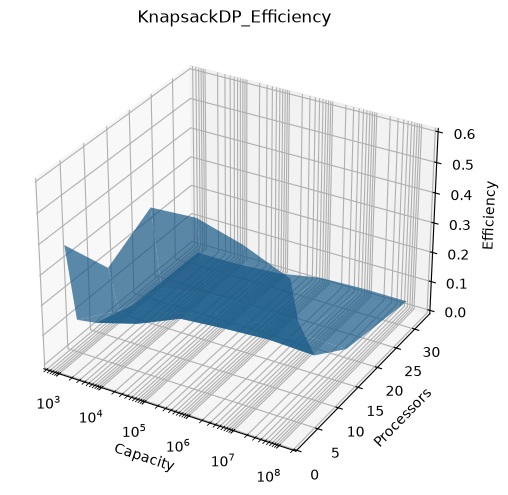

In [41]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sm = data[data['testtype'] == 'shared memory']
dp = sm[sm['testname'] == 'knapsackdp'].copy()
dp['cost'] = dp['processors'] * dp['time']

baseline = dp[dp['processors'] == 1][['capacity', 'time']].rename(
    columns={'time': 'time_base'})
multi = dp[dp['processors'] > 1].merge(baseline, on='capacity')
multi['speedup'] = multi['time_base'] / multi['time']
multi['efficiency'] = multi['speedup'] / multi['processors']

capacities = sorted(dp['capacity'].unique())
procs_all = sorted(dp['processors'].unique())
procs_multi = sorted(multi['processors'].unique())
C_all, P_all = np.meshgrid(capacities, procs_all)
C_multi, P_multi = np.meshgrid(capacities, procs_multi)

Z_cost = dp.pivot_table(index='processors', columns='capacity',
                        values='cost').values
Z_speedup = multi.pivot_table(index='processors', columns='capacity',
                              values='speedup').values
Z_efficiency = multi.pivot_table(index='processors', columns='capacity',
                                 values='efficiency').values

import os
os.makedirs('images', exist_ok=True)

plot_specs = [
    (C_all, P_all, Z_cost, 'KnapsackDP_Cost', 'Cost (processors \u00d7 time)'),
    (C_multi, P_multi, Z_speedup, 'KnapsackDP_Speedup', 'Speedup'),
    (C_multi, P_multi, Z_efficiency, 'KnapsackDP_Efficiency', 'Efficiency'),
]

for C, P, Z, title, zlabel in plot_specs:
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(C, P, Z, alpha=0.7)
    ax.set_xlabel('Capacity')
    ax.set_ylabel('Processors')
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    ax.set_xscale('log')
    plt.tight_layout()
    fig.savefig(f'images/{title}.png')
    plt.show()

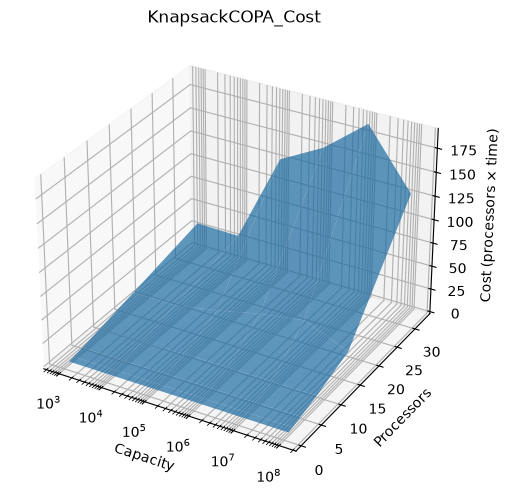

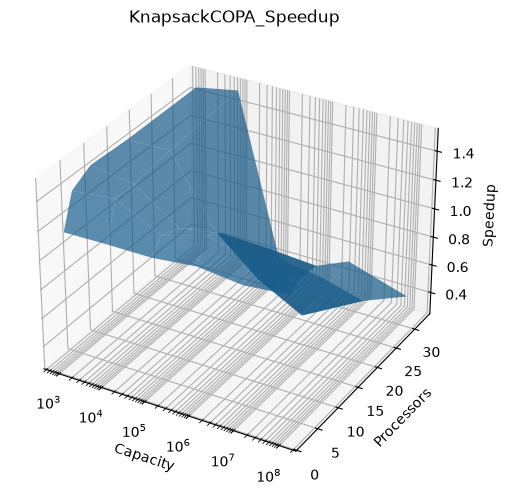

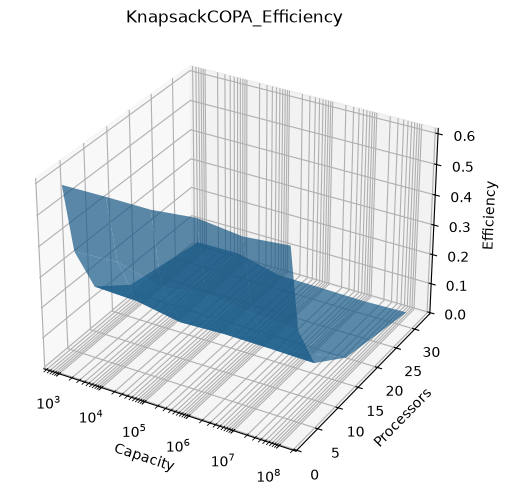

In [42]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sm = data[data['testtype'] == 'shared memory']
copa = sm[sm['testname'] == 'knapsackcopa'].copy()
copa['cost'] = copa['processors'] * copa['time']

baseline = copa[copa['processors'] == 1][['capacity', 'time']].rename(
    columns={'time': 'time_base'})
multi = copa[copa['processors'] > 1].merge(baseline, on='capacity')
multi['speedup'] = multi['time_base'] / multi['time']
multi['efficiency'] = multi['speedup'] / multi['processors']

capacities = sorted(copa['capacity'].unique())
procs_all = sorted(copa['processors'].unique())
procs_multi = sorted(multi['processors'].unique())
C_all, P_all = np.meshgrid(capacities, procs_all)
C_multi, P_multi = np.meshgrid(capacities, procs_multi)

Z_cost = copa.pivot_table(index='processors', columns='capacity',
                          values='cost').values
Z_speedup = multi.pivot_table(index='processors', columns='capacity',
                              values='speedup').values
Z_efficiency = multi.pivot_table(index='processors', columns='capacity',
                                 values='efficiency').values

plot_specs = [
    (C_all, P_all, Z_cost, 'KnapsackCOPA_Cost', 'Cost (processors \u00d7 time)'),
    (C_multi, P_multi, Z_speedup, 'KnapsackCOPA_Speedup', 'Speedup'),
    (C_multi, P_multi, Z_efficiency, 'KnapsackCOPA_Efficiency', 'Efficiency'),
]

for C, P, Z, title, zlabel in plot_specs:
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(C, P, Z, alpha=0.7)
    ax.set_xlabel('Capacity')
    ax.set_ylabel('Processors')
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    ax.set_xscale('log')
    plt.tight_layout()
    fig.savefig(f'images/{title}.png')
    plt.show()

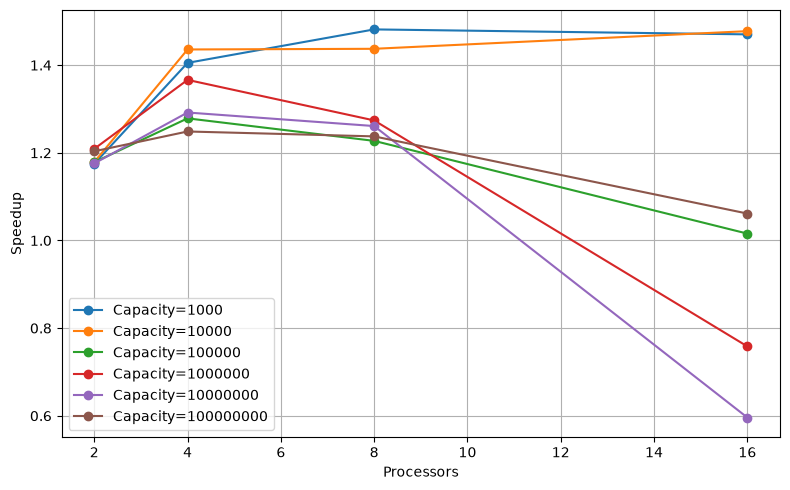

In [43]:
import matplotlib.pyplot as plt
import numpy as np

sm = data[data['testtype'] == 'shared memory']
copa = sm[sm['testname'] == 'knapsackcopa'].copy()

baseline = copa[copa['processors'] == 1][['capacity', 'time']].rename(
    columns={'time': 'time_base'})
multi = copa[copa['processors'] > 1].merge(baseline, on='capacity')
multi['speedup'] = multi['time_base'] / multi['time']

multi_12 = multi[multi['processors'] <= 16]

fig, ax = plt.subplots(figsize=(8, 5))

for cap in sorted(multi_12['capacity'].unique()):
    subset = multi_12[multi_12['capacity'] == cap].sort_values('processors')
    ax.plot(subset['processors'], subset['speedup'], marker='o', label=f'Capacity={cap}')

ax.set_xlabel('Processors')
ax.set_ylabel('Speedup')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("images/KnapsackCOPA_speedupplot.png")
plt.show()

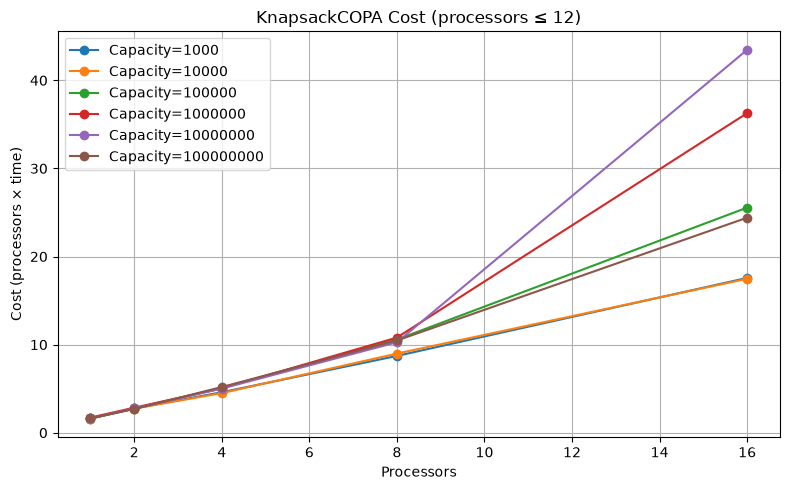

In [44]:
import matplotlib.pyplot as plt
import numpy as np

sm = data[data['testtype'] == 'shared memory']
copa = sm[sm['testname'] == 'knapsackcopa'].copy()
copa['cost'] = copa['processors'] * copa['time']

copa_12 = copa[copa['processors'] <= 16]

fig, ax = plt.subplots(figsize=(8, 5))

for cap in sorted(copa_12['capacity'].unique()):
    subset = copa_12[copa_12['capacity'] == cap].sort_values('processors')
    ax.plot(subset['processors'], subset['cost'], marker='o', label=f'Capacity={cap}')

ax.set_xlabel('Processors')
ax.set_ylabel('Cost (processors \u00d7 time)')
ax.set_title('KnapsackCOPA Cost (processors \u2264 12)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

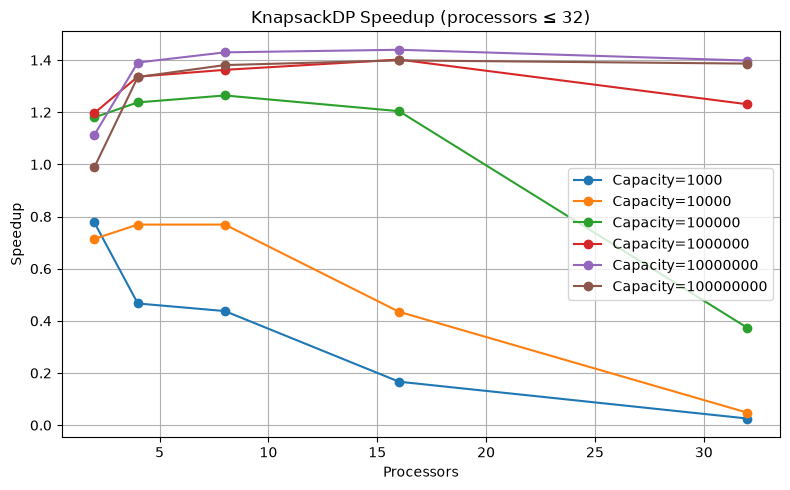

In [45]:
import matplotlib.pyplot as plt
import numpy as np

sm = data[data['testtype'] == 'shared memory']
dp = sm[sm['testname'] == 'knapsackdp'].copy()

baseline = dp[dp['processors'] == 1][['capacity', 'time']].rename(
    columns={'time': 'time_base'})
multi = dp[dp['processors'] > 1].merge(baseline, on='capacity')
multi['speedup'] = multi['time_base'] / multi['time']

fig, ax = plt.subplots(figsize=(8, 5))

for cap in sorted(multi['capacity'].unique()):
    subset = multi[multi['capacity'] == cap].sort_values('processors')
    ax.plot(subset['processors'], subset['speedup'], marker='o', label=f'Capacity={cap}')

ax.set_xlabel('Processors')
ax.set_ylabel('Speedup')
ax.set_title('KnapsackDP Speedup (processors \u2264 32)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("images/KnapsackDP_speedupplot.png")
plt.show()

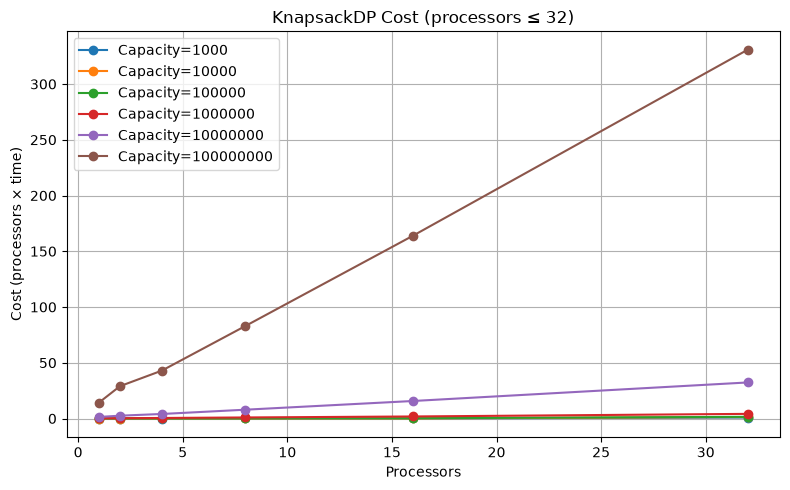

In [46]:
import matplotlib.pyplot as plt
import numpy as np

sm = data[data['testtype'] == 'shared memory']
dp = sm[sm['testname'] == 'knapsackdp'].copy()
dp['cost'] = dp['processors'] * dp['time']

fig, ax = plt.subplots(figsize=(8, 5))

for cap in sorted(dp['capacity'].unique()):
    subset = dp[dp['capacity'] == cap].sort_values('processors')
    ax.plot(subset['processors'], subset['cost'], marker='o', label=f'Capacity={cap}')

ax.set_xlabel('Processors')
ax.set_ylabel('Cost (processors \u00d7 time)')
ax.set_title('KnapsackDP Cost (processors \u2264 32)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

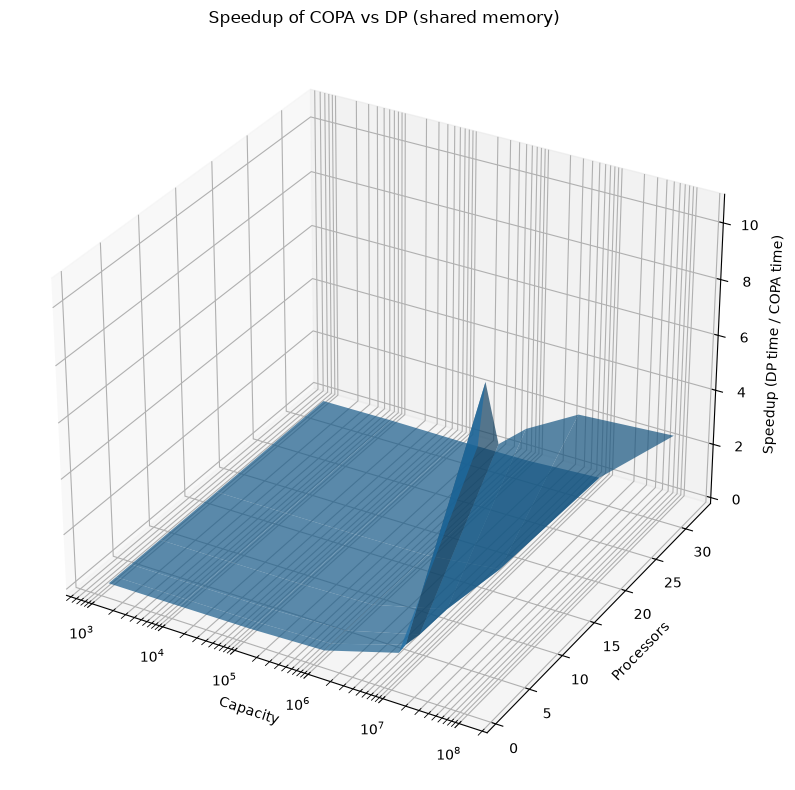

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sm = data[data['testtype'] == 'shared memory']

dp = sm[sm['testname'] == 'knapsackdp'][['capacity', 'processors', 'time']].rename(
    columns={'time': 'time_dp'})
copa = sm[sm['testname'] == 'knapsackcopa'][['capacity', 'processors', 'time']].rename(
    columns={'time': 'time_copa'})

merged = dp.merge(copa, on=['capacity', 'processors'])
merged['ratio'] = merged['time_dp'] / merged['time_copa']

capacities = sorted(merged['capacity'].unique())
processors = sorted(merged['processors'].unique())
C, P = np.meshgrid(capacities, processors)
Z = merged.pivot_table(index='processors', columns='capacity',
                       values='ratio').values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(C, P, Z, alpha=0.7)

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Speedup (DP time / COPA time)')
ax.set_title('Speedup of COPA vs DP (shared memory)')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

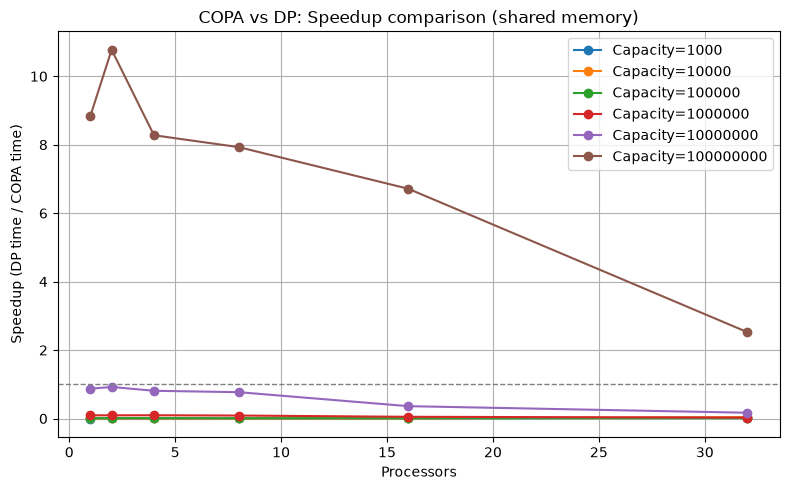

In [48]:
import matplotlib.pyplot as plt
import numpy as np

sm = data[data['testtype'] == 'shared memory']

dp = sm[sm['testname'] == 'knapsackdp'][['capacity', 'processors', 'time']].rename(
    columns={'time': 'time_dp'})
copa = sm[sm['testname'] == 'knapsackcopa'][['capacity', 'processors', 'time']].rename(
    columns={'time': 'time_copa'})

merged = dp.merge(copa, on=['capacity', 'processors'])
merged['ratio'] = merged['time_dp'] / merged['time_copa']

fig, ax = plt.subplots(figsize=(8, 5))

for cap in sorted(merged['capacity'].unique()):
    subset = merged[merged['capacity'] == cap].sort_values('processors')
    ax.plot(subset['processors'], subset['ratio'], marker='o', label=f'Capacity={cap}')

ax.axhline(y=1, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Processors')
ax.set_ylabel('Speedup (DP time / COPA time)')
ax.set_title('COPA vs DP: Speedup comparison (shared memory)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("images/knapsackdpvscopashared.png")
plt.show()

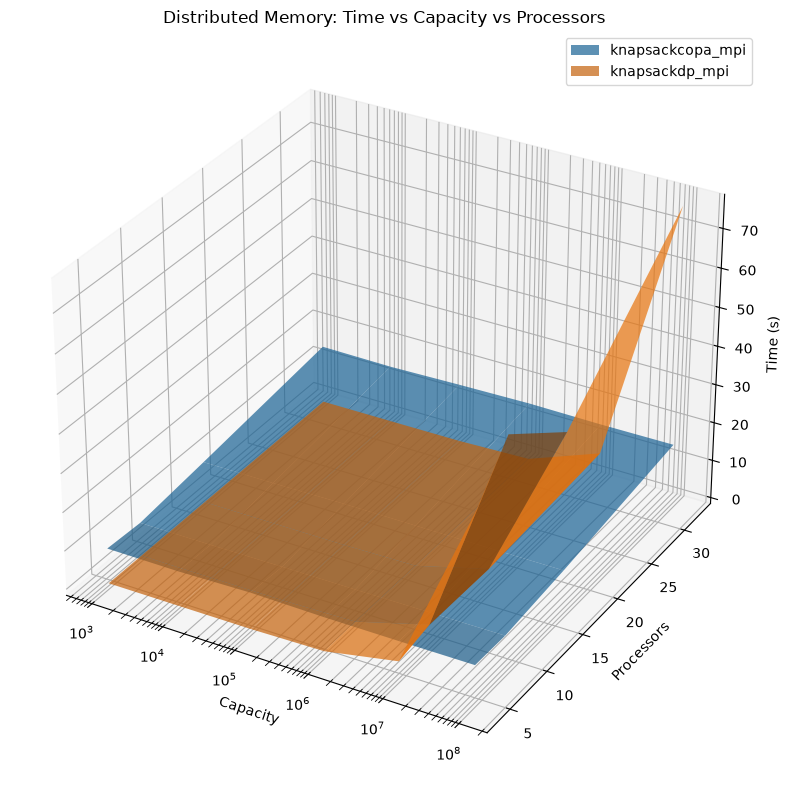

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

dm = data[data['testtype'] == 'distributed memory']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for testname in dm['testname'].unique():
    subset = dm[dm['testname'] == testname]
    capacities = sorted(subset['capacity'].unique())
    processors = sorted(subset['processors'].unique())
    C, P = np.meshgrid(capacities, processors)
    Z = subset.pivot_table(index='processors', columns='capacity',
                           values='time').values
    ax.plot_surface(C, P, Z, label=testname, alpha=0.7)

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Time (s)')
ax.set_title('Distributed Memory: Time vs Capacity vs Processors')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

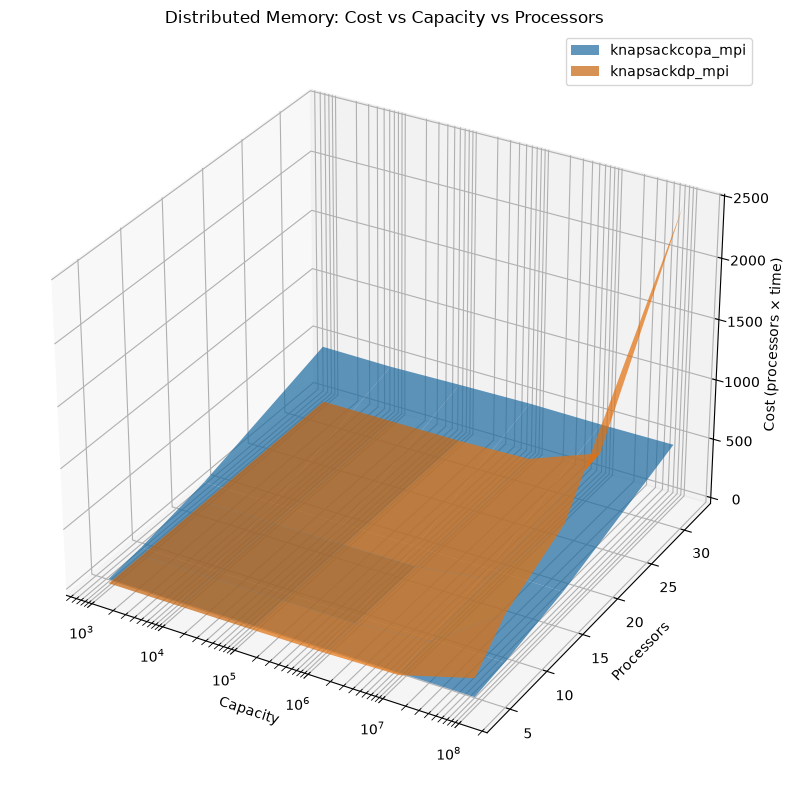

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

dm = data[data['testtype'] == 'distributed memory'].copy()
dm['cost'] = dm['processors'] * dm['time']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for testname in dm['testname'].unique():
    subset = dm[dm['testname'] == testname]
    capacities = sorted(subset['capacity'].unique())
    processors = sorted(subset['processors'].unique())
    C, P = np.meshgrid(capacities, processors)
    Z = subset.pivot_table(index='processors', columns='capacity',
                           values='cost').values
    ax.plot_surface(C, P, Z, label=testname, alpha=0.7)

ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Cost (processors \u00d7 time)')
ax.set_title('Distributed Memory: Cost vs Capacity vs Processors')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.show()

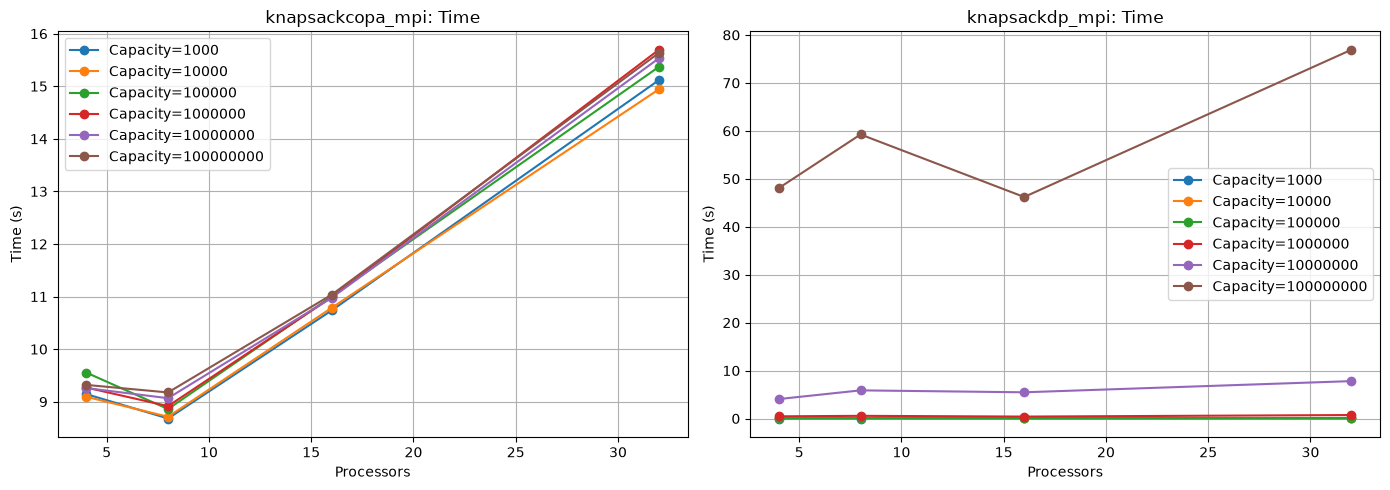

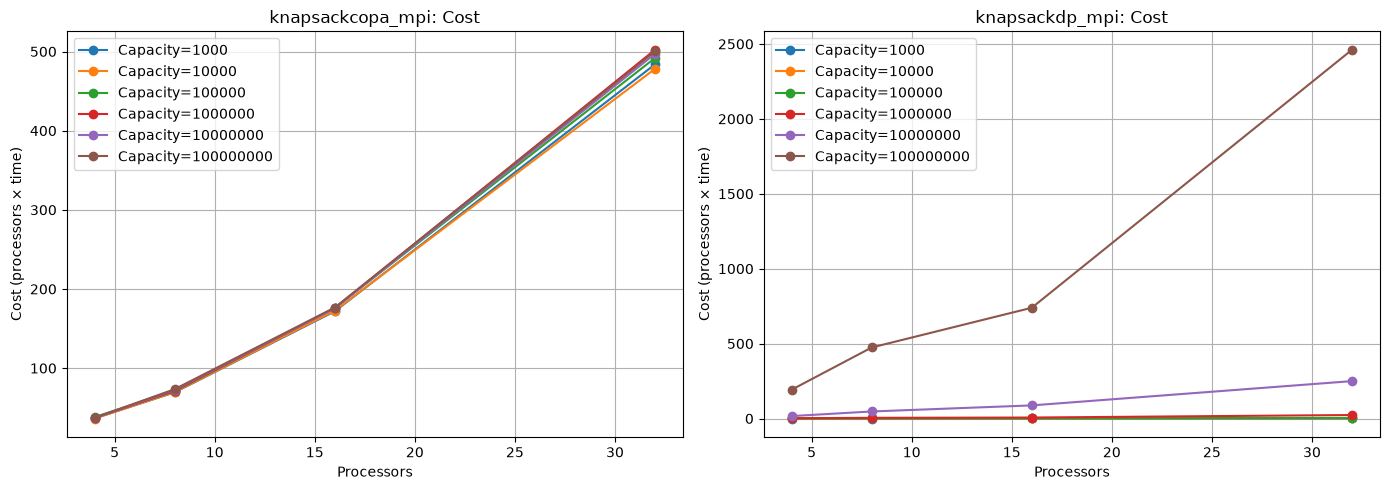

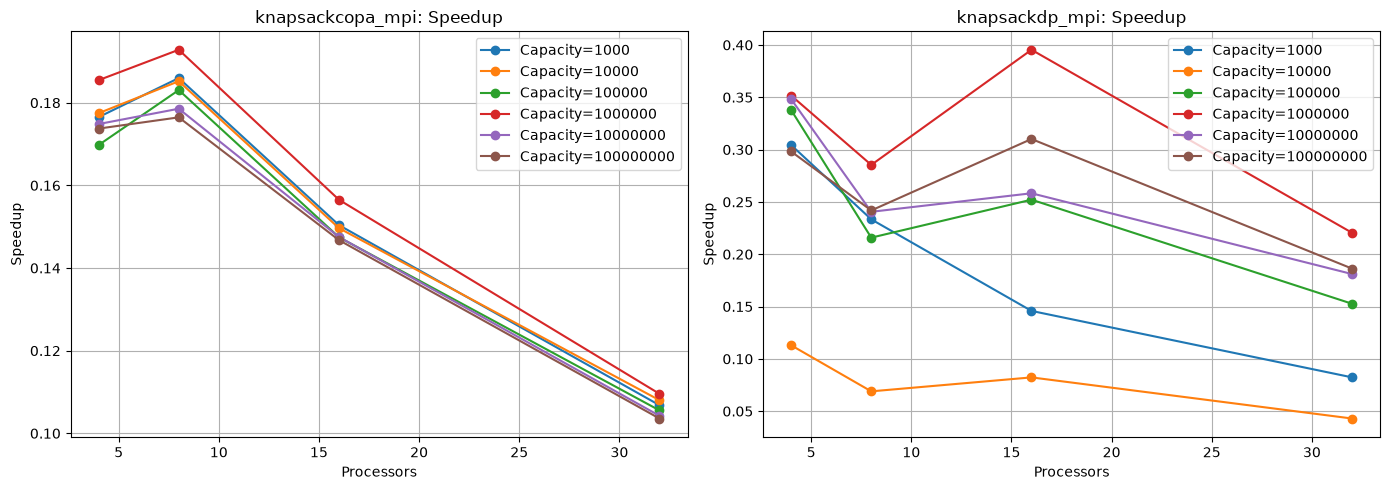

In [54]:
import matplotlib.pyplot as plt
import numpy as np

dm = data[data['testtype'] == 'distributed memory'].copy()
dm['cost'] = dm['processors'] * dm['time']

sm_baseline = data[(data['testtype'] == 'shared memory') & (data['processors'] == 1)]
name_map = {'knapsackdp': 'knapsackdp_mpi', 'knapsackcopa': 'knapsackcopa_mpi'}
baseline = sm_baseline[['testname', 'capacity', 'time']].copy()
baseline['mpi_name'] = baseline['testname'].map(name_map)
merged = dm.merge(baseline, left_on=['testname', 'capacity'],
                  right_on=['mpi_name', 'capacity'], suffixes=('', '_base'))
merged['speedup'] = merged['time_base'] / merged['time']
dm_sp = dm.merge(merged[['testname', 'capacity', 'processors', 'speedup']],
                  on=['testname', 'capacity', 'processors'])

for metric, ylabel, title_label in [
    ('time', 'Time (s)', 'Time'),
    ('cost', 'Cost (processors \u00d7 time)', 'Cost'),
    ('speedup', 'Speedup', 'Speedup'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, testname in zip(axes, dm_sp['testname'].unique()):
        subset = dm_sp[dm_sp['testname'] == testname]
        for cap in sorted(subset['capacity'].unique()):
            s = subset[subset['capacity'] == cap].sort_values('processors')
            ax.plot(s['processors'], s[metric], marker='o', label=f'Capacity={cap}')
        ax.set_xlabel('Processors')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{testname}: {title_label}')
        ax.legend()
        ax.grid(True)
        fig.savefig(f"images/{testname}_mpi.png")
    plt.tight_layout()
    plt.show()

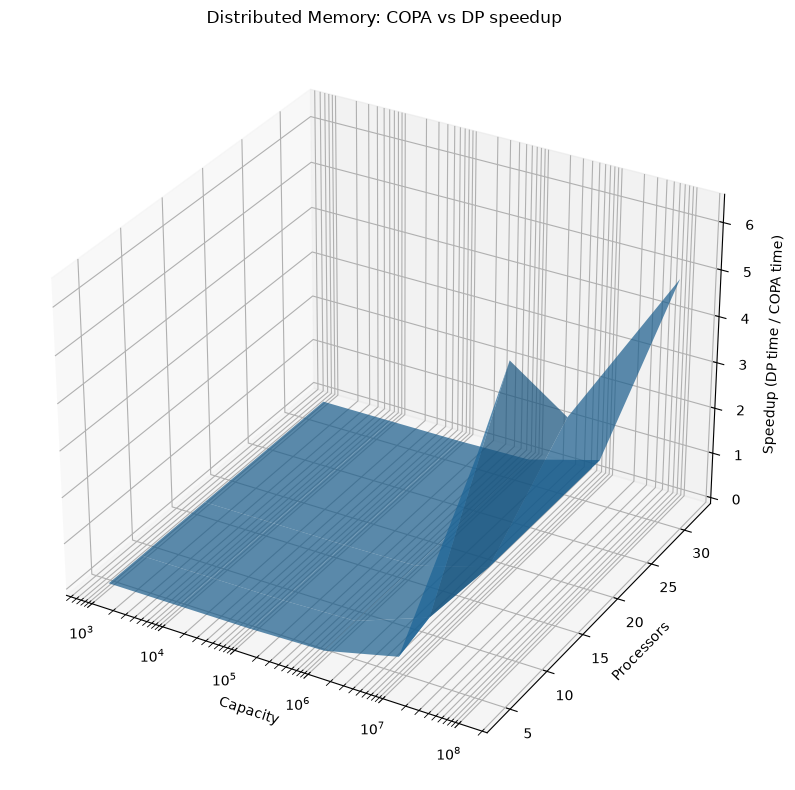

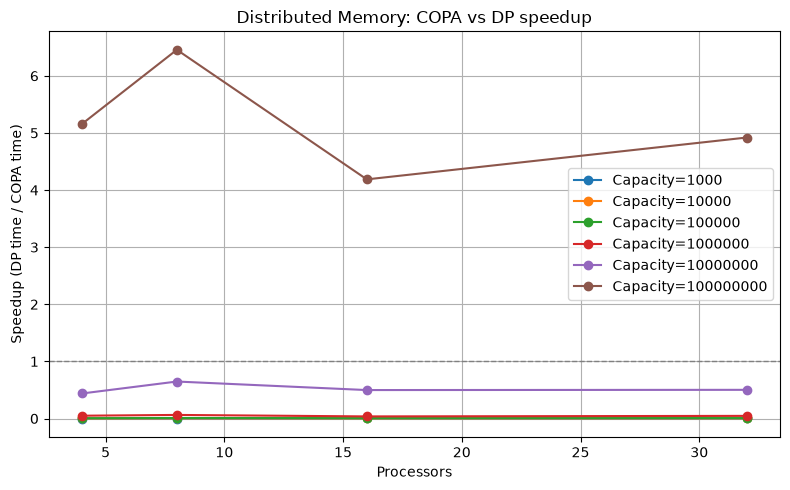

In [55]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

dm = data[data['testtype'] == 'distributed memory']

dp = dm[dm['testname'] == 'knapsackdp_mpi'][['capacity', 'processors', 'time']].rename(
    columns={'time': 'time_dp'})
copa = dm[dm['testname'] == 'knapsackcopa_mpi'][['capacity', 'processors', 'time']].rename(
    columns={'time': 'time_copa'})

merged = dp.merge(copa, on=['capacity', 'processors'])
merged['ratio'] = merged['time_dp'] / merged['time_copa']

capacities = sorted(merged['capacity'].unique())
processors = sorted(merged['processors'].unique())
C, P = np.meshgrid(capacities, processors)
Z = merged.pivot_table(index='processors', columns='capacity',
                       values='ratio').values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(C, P, Z, alpha=0.7)
ax.set_xlabel('Capacity')
ax.set_ylabel('Processors')
ax.set_zlabel('Speedup (DP time / COPA time)')
ax.set_title('Distributed Memory: COPA vs DP speedup')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
for cap in sorted(merged['capacity'].unique()):
    subset = merged[merged['capacity'] == cap].sort_values('processors')
    ax2.plot(subset['processors'], subset['ratio'], marker='o', label=f'Capacity={cap}')
ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('Processors')
ax2.set_ylabel('Speedup (DP time / COPA time)')
ax2.set_title('Distributed Memory: COPA vs DP speedup')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig("images/knapsacopavsdpdist.png")
plt.show()

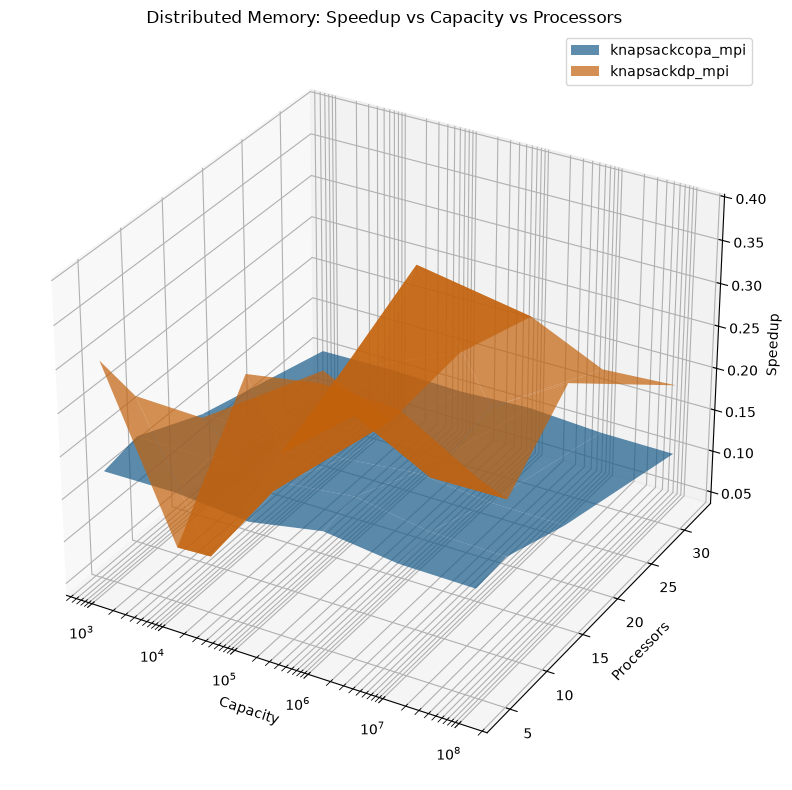

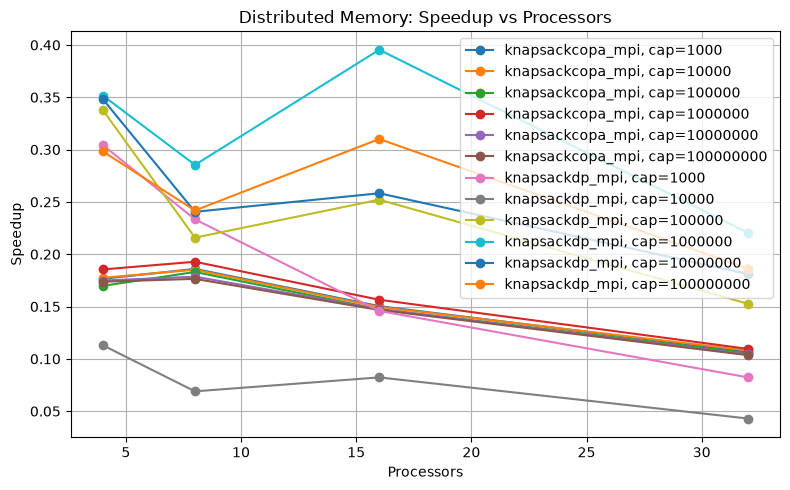

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sm_baseline = data[(data['testtype'] == 'shared memory') & (data['processors'] == 1)]
dm = data[data['testtype'] == 'distributed memory']

# Map test names: knapsackdp -> knapsackdp_mpi, knapsackcopa -> knapsackcopa_mpi
name_map = {
    'knapsackdp': 'knapsackdp_mpi',
    'knapsackcopa': 'knapsackcopa_mpi',
}

baseline = sm_baseline[['testname', 'capacity', 'time']].copy()
baseline['mpi_name'] = baseline['testname'].map(name_map)

merged = dm.merge(baseline, left_on=['testname', 'capacity'],
                  right_on=['mpi_name', 'capacity'], suffixes=('', '_base'))
merged['speedup'] = merged['time_base'] / merged['time']

for plot_type in ['surface', 'line']:
    if plot_type == 'surface':
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig, ax = plt.subplots(figsize=(8, 5))

    for testname in merged['testname'].unique():
        subset = merged[merged['testname'] == testname]
        capacities = sorted(subset['capacity'].unique())
        processors = sorted(subset['processors'].unique())

        if plot_type == 'surface':
            C, P = np.meshgrid(capacities, processors)
            Z = subset.pivot_table(index='processors', columns='capacity',
                                   values='speedup').values
            ax.plot_surface(C, P, Z, label=testname, alpha=0.7)
        else:
            for cap in capacities:
                s = subset[subset['capacity'] == cap].sort_values('processors')
                ax.plot(s['processors'], s['speedup'], marker='o',
                        label=f'{testname}, cap={cap}')

    if plot_type == 'surface':
        ax.set_xlabel('Capacity')
        ax.set_ylabel('Processors')
        ax.set_zlabel('Speedup')
        ax.set_title('Distributed Memory: Speedup vs Capacity vs Processors')
        ax.set_xscale('log')
        ax.legend()
    else:
        ax.set_xlabel('Processors')
        ax.set_ylabel('Speedup')
        ax.set_title('Distributed Memory: Speedup vs Processors')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()